# Notebook 4 — Benchmark (RAG full vs FT-only vs Hybrid)

מחברת זו מריצה ניסויים להשוואה בין שלוש חלופות בלבד (ללא מודל בסיס לא מאומן):

1. **RAG_full** — שימוש בשליפה מכלל הידע (אינדקס *full* שמכסה יציב+דינאמי), מודל הבסיס ללא FT.
2. **FT_only** — שימוש במודל לאחר Fine-Tuning על מסמכים יציבים בלבד (ללא שליפה).
3. **Hybrid_dynamic** — מודל לאחר FT על יציבים **+** שליפה מהאינדקס הדינאמי בלבד.

המחברת יודעת לעבוד עם כמה סטי טסט אם קיימים:
- `test_dynamic_qas.jsonl` — שאלות על ידע דינאמי.
- `test_stable_qas.jsonl` — שאלות על ידע יציב.
- (אופציונלי) `test_mixed_qas.jsonl` — שילוב שניתן ליצור כאן אם תרצו.

תוצרי הריצה נשמרים כ-**per-example** ו-**aggregated** + גרפים.


In [1]:
# === CONFIG ===
from pathlib import Path

WORKDIR = Path("/content/ft_vs_rag_multidata")

FAISS_FULL_DIR    = WORKDIR / "faiss_index_full"      # יציב+דינאמי
FAISS_DYNAMIC_DIR = WORKDIR / "faiss_index_dynamic"   # דינאמי בלבד

TEST_DYNAMIC_QAS  = WORKDIR / "test_dynamic_qas.jsonl"
TEST_STABLE_QAS   = WORKDIR / "test_stable_qas.jsonl"
TEST_MIXED_QAS    = WORKDIR / "test_mixed_qas.jsonl"  # נבנה אופציונלית
TRAIN_DOCS    = WORKDIR / "stable_docs.jsonl"

BASE_MODEL_NAME   = "mistralai/Mistral-7B-Instruct-v0.2"  # לשנות לפי הצורך
ADAPTER_STAGE2    = WORKDIR / "adapters" / "stage2"

EMB_MODEL_NAME    = "sentence-transformers/all-mpnet-base-v2"
TOP_K = 5

RESULTS_DIR = WORKDIR / "benchmark_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("WORKDIR:", WORKDIR)
print("Results will be saved to:", RESULTS_DIR)

WORKDIR: /content/ft_vs_rag_multidata
Results will be saved to: /content/ft_vs_rag_multidata/benchmark_results


In [2]:
from google.colab import drive
from pathlib import Path
import shutil

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define paths based on user's description and existing WORKDIR and configured paths
WORKDIR = Path("/content/ft_vs_rag_multidata")
GDRIVE_BASE_PATH = Path('/content/drive/MyDrive/ft_vs_rag_project/ft_vs_rag_multidata')
GDRIVE_DATA_HOTPOT_PATH = GDRIVE_BASE_PATH / 'data_hotpot'

# These are defined in cell a7aec959 and used as destinations
FAISS_FULL_DIR    = WORKDIR / "faiss_index_full"
FAISS_DYNAMIC_DIR = WORKDIR / "faiss_index_dynamic"
ADAPTER_STAGE2    = WORKDIR / "adapters" / "stage2"
TEST_DYNAMIC_QAS  = WORKDIR / "test_dynamic_qas.jsonl"
TEST_STABLE_QAS   = WORKDIR / "test_stable_qas.jsonl"
TRAIN_DOCS    = WORKDIR / "stable_docs.jsonl"

# List of items to copy: (source_path_on_drive, destination_path_in_colab, is_directory)
files_to_copy = [
    (GDRIVE_BASE_PATH / "faiss_index_dynamic", FAISS_DYNAMIC_DIR, True),
    (GDRIVE_BASE_PATH / "faiss_index_full", FAISS_FULL_DIR, True),
    (GDRIVE_BASE_PATH / "stage2", ADAPTER_STAGE2, True), # Assuming 'stage2' is a directory containing adapter files
    (GDRIVE_DATA_HOTPOT_PATH / "test_dynamic_qas.jsonl", TEST_DYNAMIC_QAS, False),
    (GDRIVE_DATA_HOTPOT_PATH / "test_stable_qas.jsonl", TEST_STABLE_QAS, False),
    (GDRIVE_DATA_HOTPOT_PATH / "stable_docs.jsonl", TRAIN_DOCS, False)
]

print(f"Copying files/directories from {GDRIVE_BASE_PATH} and {GDRIVE_DATA_HOTPOT_PATH} to {WORKDIR}...")

for src, dst, is_dir in files_to_copy:
    if src.exists():
        print(f"Copying {'directory' if is_dir else 'file'} {src.name} to {dst}/")
        if is_dir:
            # For directories, use copytree. Create parent if not exists. If dst exists, merge (dirs_exist_ok=True)
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            # For files, ensure parent directory exists and then copy
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy(src, dst)
    else:
        print(f"Warning: Source {'directory' if is_dir else 'file'} not found - {src}. Skipping.")

print("File/directory copying complete.")


Mounting Google Drive...
Mounted at /content/drive
Copying files/directories from /content/drive/MyDrive/ft_vs_rag_project/ft_vs_rag_multidata and /content/drive/MyDrive/ft_vs_rag_project/ft_vs_rag_multidata/data_hotpot to /content/ft_vs_rag_multidata...
Copying directory faiss_index_dynamic to /content/ft_vs_rag_multidata/faiss_index_dynamic/
Copying directory faiss_index_full to /content/ft_vs_rag_multidata/faiss_index_full/
Copying directory stage2 to /content/ft_vs_rag_multidata/adapters/stage2/
Copying file test_dynamic_qas.jsonl to /content/ft_vs_rag_multidata/test_dynamic_qas.jsonl/
Copying file test_stable_qas.jsonl to /content/ft_vs_rag_multidata/test_stable_qas.jsonl/
Copying file stable_docs.jsonl to /content/ft_vs_rag_multidata/stable_docs.jsonl/
File/directory copying complete.


In [3]:
# === Install deps (idempotent) ===
import sys, subprocess
def pipi(pkg): subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for p in [
    "transformers>=4.44.0",
    "accelerate",
    "sentence-transformers",
    "faiss-cpu",
    "datasets>=2.19.0",
    "evaluate",
    "scipy",
    "matplotlib",
    "bitsandbytes",
    "rouge_score", # Added missing dependency
    "sacrebleu"    # Added missing dependency for chrF
]:
    pipi(p)

print("Done installing (silent).")

Done installing (silent).


In [4]:
# === Utils: JSONL, timing ===
import json, time
from pathlib import Path

def read_jsonl(p: Path):
    rows = []
    if not p.exists(): return rows
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def write_jsonl(p: Path, rows):
    with p.open("w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

class Timer:
    def __enter__(self):
        self.t0 = time.time()
        return self
    def __exit__(self, exc_type, exc, tb):
        self.dt = time.time() - self.t0


In [5]:
import evaluate
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
chrf_metric = evaluate.load("chrf")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [33]:
# === Metrics (מורחב) ===
import re, numpy as np
from collections import Counter
import pandas as pd

# === New metrics ===

def normalize_doc_id(s):
    return s.lower().replace("_", " ").strip()

def retrieval_recall_at_k(supporting_docs, retrieved_docs):
    if not supporting_docs:
        return None

    sup = {normalize_doc_id(x) for x in supporting_docs}

    retrieved_ids = {
        normalize_doc_id(d.get("doc_id",""))
        for d in retrieved_docs
    }

    return len(sup & retrieved_ids) / len(sup)

def simplify_title(title_or_id):
    """מסיר את הסיומת ::chunkN ומוריד רווחים/אותיות גדולות"""
    return normalize_answer(title_or_id.split("::")[0])

def retrieval_recall_at_k(supporting_docs, retrieved_docs):
    if not supporting_docs:
        return None
    retrieved_titles = {simplify_title(d.get("title", "")) for d in retrieved_docs}
    sup = {simplify_title(t) for t in supporting_docs}
    return len(sup & retrieved_titles) / len(sup)



def answer_length(pred):
    return len(normalize_answer(pred).split())


def is_nonempty(pred):
    return int(len(normalize_answer(pred)) > 0)
############

def normalize_answer(s):
    if s is None: return ""
    s = str(s).lower()
    s = re.sub(r'\b(a|an|the)\b',' ',s)
    s = re.sub(r'[^\w\s]','',s)
    s = ' '.join(s.split())
    return s.strip()

def exact_match(pred, gold): return int(normalize_answer(pred) == normalize_answer(gold))

def f1_score(pred, gold):
    p = normalize_answer(pred).split(); g = normalize_answer(gold).split()
    common = Counter(p) & Counter(g); num_same = sum(common.values())
    if num_same == 0: return 0.0
    prec = num_same/max(1,len(p)); rec = num_same/max(1,len(g))
    return 2*prec*rec/(prec+rec)

#try:
#    import evaluate
#    bleu_metric = evaluate.load("bleu")
#    rouge_metric = evaluate.load("rouge")
#    chrf_metric = evaluate.load("chrf")
#except Exception:
#    bleu_metric = rouge_metric = chrf_metric = None

try:
    from sentence_transformers import SentenceTransformer
    sbert = SentenceTransformer("all-mpnet-base-v2")
except Exception:
    sbert = None

def semantic_similarity(pred, gold):
    if sbert is None: return None
    emb = sbert.encode([pred, gold], convert_to_numpy=True)
    a, b = emb[0], emb[1]
    den = (np.linalg.norm(a)*np.linalg.norm(b))
    return float(np.dot(a,b)/den) if den>0 else 0.0

def citation_precision(pred, retrieved_docs, ngram=1):
    def ngrams(tokens, n):
        return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)] if len(tokens)>=n else tokens
    toks = normalize_answer(pred).split()
    doc_text = " ".join([normalize_answer(d.get("text","")) for d in retrieved_docs])
    pred_ngrams = set(ngrams(toks, ngram)); doc_ngrams = set(ngrams(doc_text.split(), ngram))
    return len(pred_ngrams & doc_ngrams)/len(pred_ngrams) if pred_ngrams else 0.0

def hallucination_fraction(pred, retrieved_docs):
    toks = normalize_answer(pred).split()
    if not toks: return 1.0
    doc_text = " ".join([normalize_answer(d.get("text","")) for d in retrieved_docs])
    matches = sum(1 for t in toks if t in doc_text)
    return 1.0 - (matches/len(toks))

def distinct_n(preds, n=1):
    all_ngrams = []
    for p in preds:
        toks = normalize_answer(p).split()
        for i in range(len(toks)-n+1):
            all_ngrams.append(" ".join(toks[i:i+n]))
    return len(set(all_ngrams))/len(all_ngrams) if all_ngrams else 0.0

def exact_leakage_fraction(preds, train_texts, min_len=20):
    train_join = " ||| ".join([normalize_answer(t) for t in train_texts])
    leaked = 0
    for p in preds:
        pn = normalize_answer(p)
        found = any(pn[i:i+min_len] in train_join for i in range(0, max(0, len(pn)-min_len+1)))
        leaked += int(found)
    return leaked/max(1,len(preds))

def build_train_ngrams(train_texts, n=5):
    s = set()
    for t in train_texts:
        toks = normalize_answer(t).split()
        for i in range(len(toks)-n+1):
            s.add(" ".join(toks[i:i+n]))
    return s

def ngram_overlap_fraction(pred, train_ngrams_set, n=5):
    toks = normalize_answer(pred).split()
    if len(toks) < n: return 0.0
    pred_ngrams = set(" ".join(toks[i:i+n]) for i in range(len(toks)-n+1))
    return len(pred_ngrams & train_ngrams_set)/max(1,len(pred_ngrams))

def longest_train_substring_len(pred, train_join, min_chars=10):
    p = normalize_answer(pred)
    for L in range(len(p), min_chars-1, -1):
        for i in range(0, len(p)-L+1):
            if p[i:i+L] in train_join: return L
    return 0

def aggregate_and_save(name, rows, results_dir, train_texts=None):
    import numpy as _np, json as _json
    preds = [r["pred"] for r in rows]; golds = [r["gold"] for r in rows]
    rets  = [r.get("retrieved_docs",[]) for r in rows]; lats = [r.get("latency") for r in rows]

    train_join = " ||| ".join([normalize_answer(t) for t in (train_texts or [])]) if train_texts else ""
    train_5grams = build_train_ngrams(train_texts, n=5) if train_texts else set()

    enriched = []
    for r in rows:
        pred, gold = r["pred"], r["gold"]
        ret, lat   = r.get("retrieved_docs",[]), r.get("latency")

        em  = exact_match(pred, gold)
        f1  = f1_score(pred, gold)
        sem = semantic_similarity(pred, gold)
        citp = citation_precision(pred, ret, ngram=1)
        hallu = hallucination_fraction(pred, ret)

        # Optional metrics
        try:
            bleu = bleu_metric.compute(
                predictions=[pred],
                references=[gold]
            ).get("bleu")
        except: bleu = None

        try:
            rougeL = rouge_metric.compute(
                predictions=[pred],
                references=[gold]
            ).get("rougeL")
           # rougeL = rouge_metric.compute(predictions=[pred], references=[gold])["rougeL"] if rouge_metric else None
        except: rougeL = None

        try:
          chrf = chrf_metric.compute(
                predictions=[pred],
                references=[gold]
            ).get("score")
            #chrf = chrf_metric.compute(predictions=[pred], references=[gold])["chrf"] if chrf_metric else None
        except: chrf = None

        ng5 = ngram_overlap_fraction(pred, train_5grams, n=5) if train_5grams else None
        #lsub = longest_train_substring_len(pred, train_join, min_chars=20) if train_join else 0

        # === New hybrid-RAG metrics ===
        retrieval_recall = retrieval_recall_at_k(r.get("supporting_docs", []), ret)

        plen = answer_length(pred)
        nonempty = is_nonempty(pred)

        enriched.append({
            **r,
            "em": em, "f1": f1, "semsim": sem,
            "cite_prec": citp, "hallu": hallu,
            "bleu": bleu, "rougeL": rougeL, "chrf": chrf,
            "ngram5_overlap": ng5, #"longest_train_substr": lsub,
            "latency": lat,
            # New metrics
            "retrieval_recall": retrieval_recall,
            "pred_length": plen,
            "nonempty": nonempty
        })

    # Write per-example
    per_path = results_dir / f"{name}_per_example_enriched.jsonl"
    with per_path.open("w", encoding="utf-8") as f:
        for ex in enriched: f.write(_json.dumps(ex, ensure_ascii=False)+"\n")

    # --- Aggregates ---
    def m(vals):
        vals = [v for v in vals if v is not None]
        return float(_np.mean(vals)) if vals else None

    agg = {
        "variant": name,
        "n": len(enriched),

        "avg_em": m([x["em"] for x in enriched]),
        "avg_f1": m([x["f1"] for x in enriched]),
        "avg_semsim": m([x["semsim"] for x in enriched]),
        "avg_bleu": m([x["bleu"] for x in enriched]),
        "avg_rougeL": m([x["rougeL"] for x in enriched]),
        "avg_chrf": m([x["chrf"] for x in enriched]),

        "avg_cite_prec": m([x["cite_prec"] for x in enriched]),
        "avg_hallu": m([x["hallu"] for x in enriched]),

        "distinct_1": distinct_n(preds, 1),
        "distinct_2": distinct_n(preds, 2),

        "avg_ngram5_overlap": m([x["ngram5_overlap"] for x in enriched]),
        #"max_longest_train_substr": max([x["longest_train_substr"] for x in enriched]) if enriched else 0,

        "avg_latency": m([x["latency"] for x in enriched]),

        # === New metrics ===
        "avg_retrieval_recall": m([x["retrieval_recall"] for x in enriched]),
        "avg_pred_length": m([x["pred_length"] for x in enriched]),
        "nonempty_rate": m([x["nonempty"] for x in enriched]),
    }

    if train_texts:
        agg["leakage_frac_min20chars"] = exact_leakage_fraction(preds, train_texts, min_len=20)

    agg_path = results_dir / f"{name}_aggregated.json"
    with agg_path.open("w", encoding="utf-8") as f:
        _json.dump(agg, f, ensure_ascii=False, indent=2)

    return enriched, agg


In [7]:
# === Retriever via FAISS ===
import faiss, numpy as np, json
from sentence_transformers import SentenceTransformer
from pathlib import Path

class SimpleFaissStore:
    def __init__(self, index_dir: Path, emb_model_name: str):
        self.index_dir = Path(index_dir)
        self.index = None
        self.passages = []
        # Force SentenceTransformer to CPU due to prior CUDA OOM errors
        self.model = SentenceTransformer(emb_model_name, device='cpu')
        self._load()

    def _load(self):
        index_path = self.index_dir / "index.faiss"
        psg_path   = self.index_dir / "passages.jsonl"
        if not index_path.exists() or not psg_path.exists():
            raise FileNotFoundError(f"Missing index/passages in {self.index_dir}")
        self.index = faiss.read_index(str(index_path))
        with psg_path.open("r", encoding="utf-8") as f:
            self.passages = [json.loads(l) for l in f if l.strip()]

    def search(self, query: str, top_k: int=5):
        q_emb = self.model.encode([query], convert_to_numpy=True)
        try:
            D, I = self.index.search(q_emb.astype(np.float32), top_k)
        except Exception as e:
            # Try dimension pad/trim
            try:
                vec = self.index.reconstruct(0)
                d_index = len(vec); d_model = q_emb.shape[1]
                if d_index > d_model:
                    pad = np.zeros((1, d_index - d_model), dtype=q_emb.dtype)
                    q_use = np.concatenate([q_emb, pad], axis=1)
                else:
                    q_use = q_emb[:, :d_index]
                D, I = self.index.search(q_use.astype(np.float32), top_k)
            except Exception as e2:
                raise RuntimeError(f"Embedding dim mismatch and auto-fix failed: {e2}") from e
        results = []
        for idx in I[0]:
            if 0 <= idx < len(self.passages):
                p = self.passages[idx]
                results.append({"id": p.get("id", idx), "text": p.get("text", "")})
        return results


In [8]:
# === Retriever via FAISS (meta.json version) ===
import faiss, numpy as np, json
from sentence_transformers import SentenceTransformer
from pathlib import Path

import json

class SimpleFaissStoreMeta:
    def __init__(self, index_dir: Path, emb_model_name: str):
        self.index_dir = Path(index_dir)
        self.index = None
        self.passages = []
        self.model = SentenceTransformer(emb_model_name, device='cpu')
        self._load()

    def _load(self):
        index_path = self.index_dir / "index.faiss"
        meta_path = self.index_dir / "meta.json"
        if not index_path.exists() or not meta_path.exists():
            raise FileNotFoundError(f"Missing index or meta file in {self.index_dir}")
        self.index = faiss.read_index(str(index_path))

        with meta_path.open("r", encoding="utf-8") as f:
            self.passages = [json.loads(l) for l in f if l.strip()]

    def search(self, query: str, top_k: int = 5):
        q_emb = self.model.encode([query], convert_to_numpy=True)
        try:
            D, I = self.index.search(q_emb.astype(np.float32), top_k)
        except Exception as e:
            # Try dimension pad/trim if mismatch occurs
            try:
                vec = self.index.reconstruct(0)
                d_index = len(vec); d_model = q_emb.shape[1]
                if d_index > d_model:
                    pad = np.zeros((1, d_index - d_model), dtype=q_emb.dtype)
                    q_use = np.concatenate([q_emb, pad], axis=1)
                else:
                    q_use = q_emb[:, :d_index]
                D, I = self.index.search(q_use.astype(np.float32), top_k)
            except Exception as e2:
                raise RuntimeError(f"Embedding dim mismatch and auto-fix failed: {e2}") from e

        # Create result list with appropriate meta data
        results = []
        for idx in I[0]:
            if 0 <= idx < len(self.passages):
                p = self.passages[idx]
                results.append({"id": p.get("doc_id", idx), "text": p.get("text", "")})
        return results


In [9]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
import torch
from pathlib import Path

def load_generation_pipeline(base_model_name: str, adapter_path: Path=None):
    # Force model to CPU due to persistent CUDA out-of-memory issues with Mistral-7B
    model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float32, # Use float32 on CPU
        device_map={'': 'cpu'} # Explicitly map all layers to CPU
    )
    tok = AutoTokenizer.from_pretrained(base_model_name, use_fast=True)

    if adapter_path and Path(adapter_path).exists():
        try:
            from peft import PeftModel
            model = PeftModel.from_pretrained(model, str(adapter_path))
            print("Loaded adapter:", adapter_path)
        except Exception as e:
            print("WARNING: failed to load adapter, continuing as base:", e)
    gen = pipeline("text-generation", model=model, tokenizer=tok)
    return gen, tok
##TODO delete

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    pipeline
)

from peft import PeftModel
import torch
from pathlib import Path

def load_generation_pipeline(base_model_name: str, adapter_path: Path=None):

  # bitsandbytes 4-bit quantization config
  bnb_config = BitsAndBytesConfig(
      load_in_4bit=True,
      bnb_4bit_compute_dtype=torch.bfloat16,
      bnb_4bit_use_double_quant=True,
      bnb_4bit_quant_type="nf4"
  )

  model = AutoModelForCausalLM.from_pretrained(
      base_model_name,
      quantization_config=bnb_config,
      device_map="auto"
  )

  tok = AutoTokenizer.from_pretrained(base_model_name, use_fast=True)

  # Load adapter if present
  if adapter_path and Path(adapter_path).exists():
      try:
          model = PeftModel.from_pretrained(model, str(adapter_path))
          print("Loaded adapter:", adapter_path)
      except Exception as e:
          print("WARNING: failed to load adapter, continuing as base:", e)

  gen = pipeline("text-generation", model=model, tokenizer=tok)
  return gen, tok


In [10]:
# === Prompt builders ===
SYS_STABLE = "You are a helpful assistant. Answer concisely and correctly."
SYS_HYBRID = "You are a helpful assistant. Use the provided CONTEXT if relevant; otherwise rely on your knowledge."

def build_prompt_no_retrieval(question: str):
    return f"{SYS_STABLE}\n\nQuestion: {question}\nAnswer:"

def build_prompt_with_context(question: str, ctx_docs):
    ctx_text = "\n\n".join([d.get("text","") for d in ctx_docs])
    return f"{SYS_HYBRID}\n\n<CONTEXT>\n{ctx_text}\n</CONTEXT>\n\nQuestion: {question}\nAnswer:"


In [11]:
def run_variant(name: str, rows, gen_pipe, retriever=None, top_k=5, max_new_tokens=256):
    out = []
    for r in rows:
        q = r.get("question","")
        gold = r.get("answer","")
        supporting_docs = r.get("supporting_docs", [])
        retrieved = []
        if retriever is not None:
            retrieved = retriever.search(q, top_k=top_k)
            prompt = build_prompt_with_context(q, retrieved)
        else:
            prompt = build_prompt_no_retrieval(q)

        with Timer() as t:
            gen = gen_pipe(prompt, max_new_tokens=max_new_tokens, do_sample=False)
        pred = gen[0]["generated_text"][len(prompt):].strip() if gen and gen[0].get("generated_text") else ""

        out.append({
            "id": r.get("id", None),
            "question": q,
            "gold": gold,
            "pred": pred,
            "supporting_docs": supporting_docs,
            "retrieved_docs": retrieved,
            "latency": t.dt
        })
    return out


In [12]:
# === Load model & retrievers ===
# Base model
gen_base, tok = load_generation_pipeline(BASE_MODEL_NAME, adapter_path=None)

# FT model
gen_ft = None
if ADAPTER_STAGE2.exists():
    try:
        gen_ft, _ = load_generation_pipeline(BASE_MODEL_NAME, adapter_path=ADAPTER_STAGE2)
    except Exception as e:
        print("WARNING: Could not load FT adapter, FT_only/Hybrid will fallback to base. Error:", e)

# Retrievers
retr_full = retr_dyn = None

# FAISS full index (meta.json)
try:
    retr_full = SimpleFaissStoreMeta(FAISS_FULL_DIR, EMB_MODEL_NAME)
    print("Loaded FAISS full index (meta.json).")
except Exception as e:
    print("WARNING: failed to load full index:", e)

# FAISS dynamic index (passages.jsonl רגיל)
try:
    retr_dyn = SimpleFaissStoreMeta(FAISS_DYNAMIC_DIR, EMB_MODEL_NAME)
    print("Loaded FAISS dynamic index.")
except Exception as e:
    print("WARNING: failed to load dynamic index:", e)


# Retrievers
#retr_full = retr_dyn = None
#try:
#    retr_full = SimpleFaissStore(FAISS_FULL_DIR, EMB_MODEL_NAME)
#    print("Loaded FAISS full index.")
#except Exception as e:
#    print("WARNING: failed to load full index:", e)

#try:
#    retr_dyn  = SimpleFaissStore(FAISS_DYNAMIC_DIR, EMB_MODEL_NAME)
#    print("Loaded FAISS dynamic index.")
#except Exception as e:
#    print("WARNING: failed to load dynamic index:", e)

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Device set to use cuda:0


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0


Loaded adapter: /content/ft_vs_rag_multidata/adapters/stage2
Loaded FAISS full index (meta.json).
Loaded FAISS dynamic index.


In [13]:
# === (Optional) Build mixed if missing ===
import random
if not TEST_MIXED_QAS.exists() and TEST_DYNAMIC_QAS.exists() and TEST_STABLE_QAS.exists():
    dyn_rows = read_jsonl(TEST_DYNAMIC_QAS)
    st_rows  = read_jsonl(TEST_STABLE_QAS)
    take_d = min(200, len(dyn_rows))
    take_s = min(200, len(st_rows))
    random.seed(0)
    mixed = random.sample(dyn_rows, take_d) + random.sample(st_rows, take_s)
    write_jsonl(TEST_MIXED_QAS, mixed)
    print(f"Created mixed set: {TEST_MIXED_QAS} ({len(mixed)} rows)")

Created mixed set: /content/ft_vs_rag_multidata/test_mixed_qas.jsonl (400 rows)


In [14]:
# === Load test sets ===
tests = []
if TEST_DYNAMIC_QAS.exists():
    tests.append(("dynamic", read_jsonl(TEST_DYNAMIC_QAS)))
if TEST_STABLE_QAS.exists():
    tests.append(("stable", read_jsonl(TEST_STABLE_QAS)))
if TEST_MIXED_QAS.exists():
    tests.append(("mixed", read_jsonl(TEST_MIXED_QAS)))

print("Found test sets:", [(n, len(r)) for n,r in tests])

Found test sets: [('dynamic', 775), ('stable', 4248), ('mixed', 400)]


In [15]:
import shutil
from pathlib import Path

RESULTS_DIR = Path("/content/ft_vs_rag_multidata/benchmark_results")

if RESULTS_DIR.exists():
    print(f"Cleaning directory: {RESULTS_DIR}")
    shutil.rmtree(RESULTS_DIR)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    print("Directory cleaned and recreated.")
else:
    print(f"Directory {RESULTS_DIR} does not exist, creating it.")
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    print("Directory created.")


Cleaning directory: /content/ft_vs_rag_multidata/benchmark_results
Directory cleaned and recreated.


In [19]:
#import json

# נניח שכל שורה היא JSON עם מפתח "text"
#train_texts = []
#with open(TRAIN_DOCS, "r", encoding="utf-8") as f:
#    for line in f:
#        doc = json.loads(line)
#        train_texts.append(doc["text"])

In [35]:
# === Run experiments ===
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt, json

aggregates = []

for test_name, rows in tests:
    rows = rows[:775]
    # RAG_full
    if retr_full is not None:
        out = run_variant(f"RAG_full__{test_name}", rows, gen_base, retriever=retr_full, top_k=TOP_K)
        write_jsonl(RESULTS_DIR / f"RAG_full__{test_name}_per_example.jsonl", out)
        _, agg = aggregate_and_save(f"RAG_full__{test_name}", out, RESULTS_DIR)#, train_texts)
        aggregates.append(agg)

    # FT_only
    gen_for_ft = gen_ft if gen_ft is not None else gen_base
    out = run_variant(f"FT_only__{test_name}", rows, gen_for_ft, retriever=None, top_k=TOP_K)
    write_jsonl(RESULTS_DIR / f"FT_only__{test_name}_per_example.jsonl", out)
    _, agg = aggregate_and_save(f"FT_only__{test_name}", out, RESULTS_DIR) #, TRAIN_DOCS)
    aggregates.append(agg)

    # Hybrid_dynamic
    if retr_dyn is not None:
        out = run_variant(f"Hybrid_dynamic__{test_name}", rows, gen_for_ft, retriever=retr_dyn, top_k=TOP_K)
        write_jsonl(RESULTS_DIR / f"Hybrid_dynamic__{test_name}_per_example.jsonl", out)
        _, agg = aggregate_and_save(f"Hybrid_dynamic__{test_name}", out, RESULTS_DIR) #, train_texts)
        aggregates.append(agg)

if aggregates:
    df = pd.DataFrame(aggregates).sort_values(["variant"])
    df.to_csv(RESULTS_DIR / "aggregated_metrics_full.csv", index=False)
    with open(RESULTS_DIR / "aggregated_metrics_full.json","w",encoding="utf-8") as f:
        json.dump(aggregates, f, ensure_ascii=False, indent=2)
    # Removed the problematic import and function call
    # from caas_jupyter_tools import display_dataframe_to_user
    # display_dataframe_to_user("Aggregated Metrics", df)
    print(df)
    print("Saved aggregated metrics to:", RESULTS_DIR / "aggregated_metrics_full.csv")
else:
    print("No results to aggregate.")


Streaming output truncated to the last 5000 lines.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generatio

                   variant    n    avg_em    avg_f1  avg_semsim  avg_bleu  \
1         FT_only__dynamic  775  0.117419  0.244641    0.546522  0.012187   
7           FT_only__mixed  400  0.187500  0.298508    0.580688  0.027506   
4          FT_only__stable  775  0.281290  0.382673    0.641866  0.024083   
2  Hybrid_dynamic__dynamic  775  0.419355  0.570352    0.745657  0.062004   
8    Hybrid_dynamic__mixed  400  0.327500  0.445959    0.667190  0.045229   
5   Hybrid_dynamic__stable  775  0.291613  0.393981    0.643881  0.016515   
0        RAG_full__dynamic  775  0.016774  0.099653    0.348424  0.007866   
6          RAG_full__mixed  400  0.007500  0.100684    0.334588  0.007795   
3         RAG_full__stable  775  0.023226  0.115474    0.352755  0.009944   

   avg_rougeL   avg_chrf  avg_cite_prec  avg_hallu  distinct_1  distinct_2  \
1    0.251365  28.510007       0.000000   1.000000    0.743368    0.962461   
7    0.308556  33.160771       0.000000   1.000000    0.774765    0.97137

<Figure size 640x480 with 0 Axes>

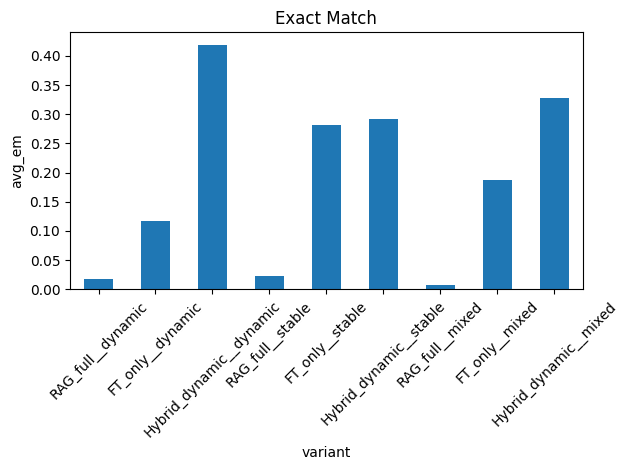

<Figure size 640x480 with 0 Axes>

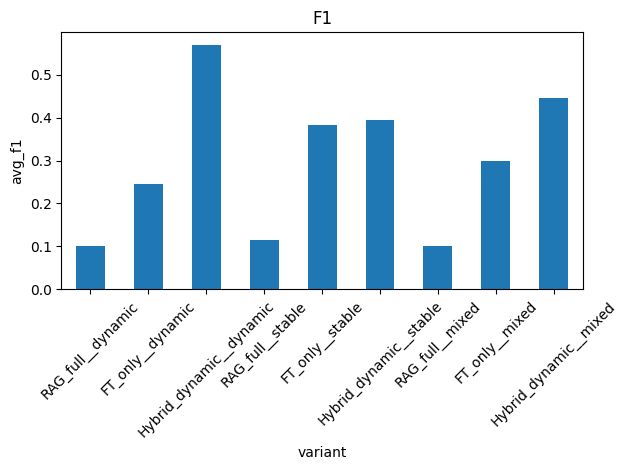

<Figure size 640x480 with 0 Axes>

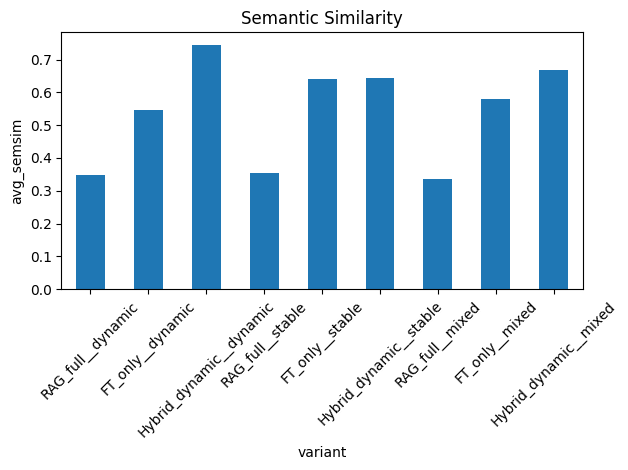

<Figure size 640x480 with 0 Axes>

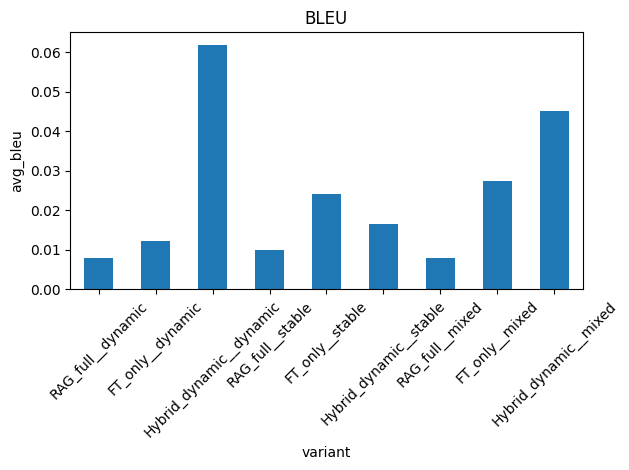

<Figure size 640x480 with 0 Axes>

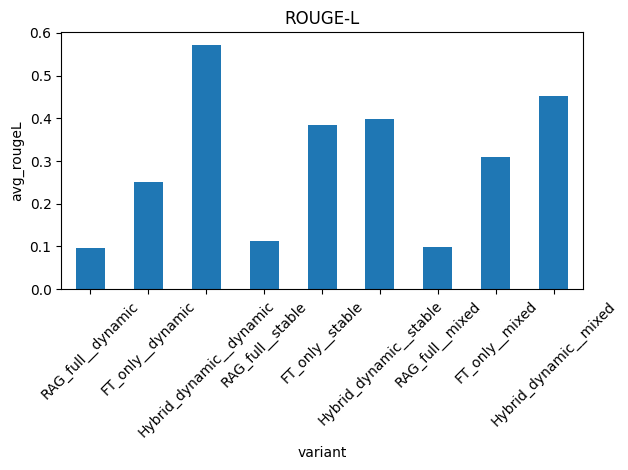

<Figure size 640x480 with 0 Axes>

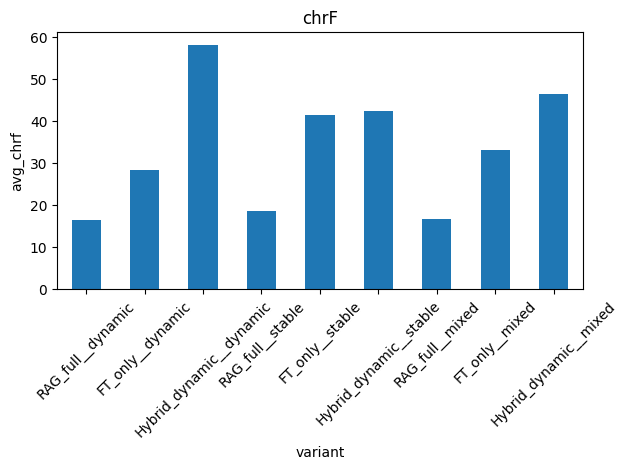

<Figure size 640x480 with 0 Axes>

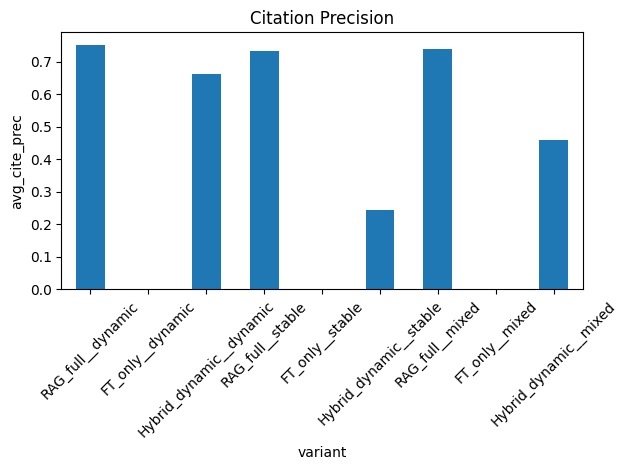

<Figure size 640x480 with 0 Axes>

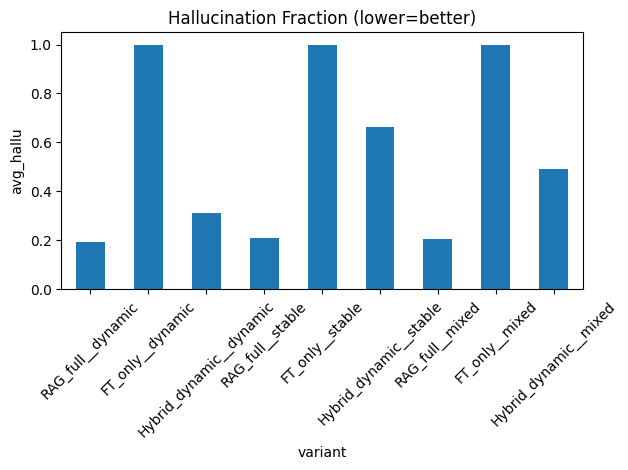

<Figure size 640x480 with 0 Axes>

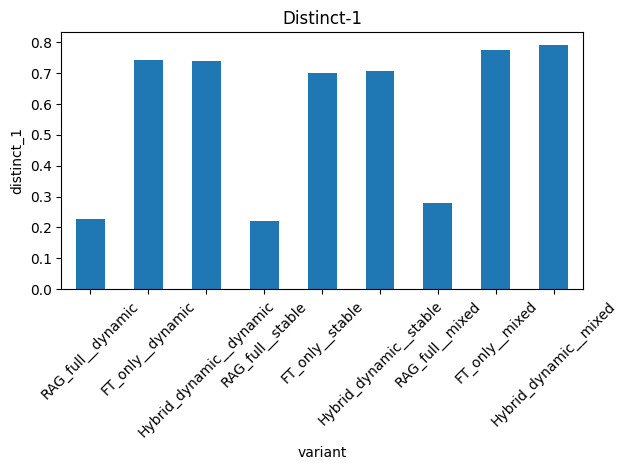

<Figure size 640x480 with 0 Axes>

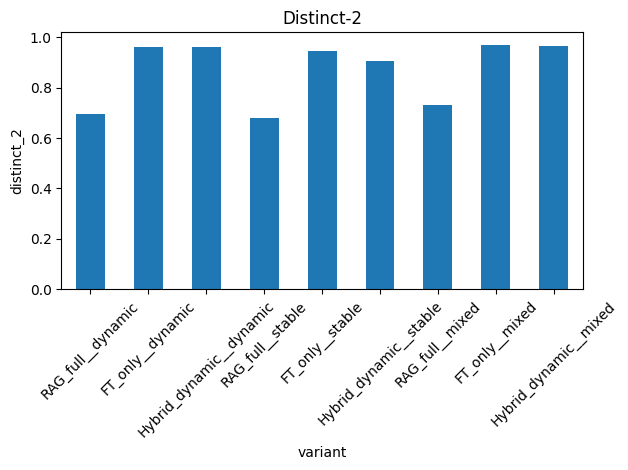

<Figure size 640x480 with 0 Axes>

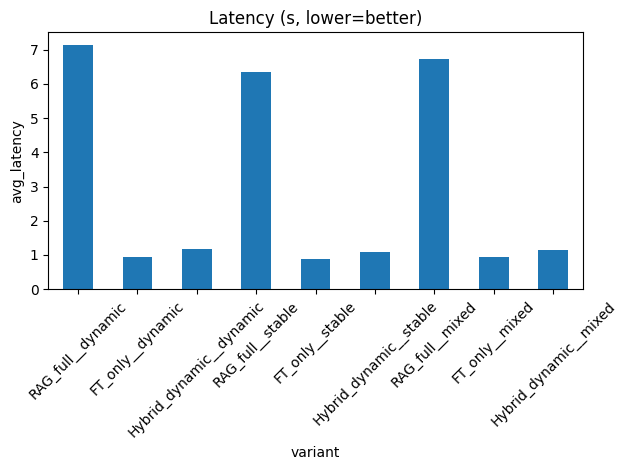

In [37]:
# === Plots ===
import pandas as pd, json, matplotlib.pyplot as plt

def plot_bar(df, metric, title):
    df2 = df[["variant", metric]].dropna()
    if df2.empty:
        print(f"No data for {metric}")
        return
    plt.figure()
    ax = df2.plot(kind="bar", x="variant", y=metric, legend=False, rot=45)
    ax.set_title(title)
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()

try:
    with open(RESULTS_DIR / "aggregated_metrics_full.json","r",encoding="utf-8") as f:
        aggs = json.load(f)
    df = pd.DataFrame(aggs)
    for metric, title in [
        ("avg_em","Exact Match"),
        ("avg_f1","F1"),
        ("avg_semsim","Semantic Similarity"),
        ("avg_bleu","BLEU"),
        ("avg_rougeL","ROUGE-L"),
        ("avg_chrf","chrF"),
        ("avg_cite_prec","Citation Precision"),
        ("avg_hallu","Hallucination Fraction (lower=better)"),
        ("distinct_1","Distinct-1"),
        ("distinct_2","Distinct-2"),
        ("avg_latency","Latency (s, lower=better)"),
    ]:
        plot_bar(df, metric, title)
except Exception as e:
    print("Plotting skipped:", e)

## הערה מתודולוגית
כדי להמחיש את התזה *"ידע ישן → FT, ידע חדש → RAG, והשילוב הוא מיטבי"* מומלץ להריץ על שלושה סטים (אם יש):
- **stable** — מדגיש יתרון ל-FT_only
- **dynamic** — מדגיש יתרון ל-RAG / Hybrid
- **mixed** — מדמה עולם אמיתי; לרוב **Hybrid_dynamic** ינצח בממוצע

לשאלה שלך: שימוש ב-`test_dynamic_qas.jsonl` תקף לשתי חלופות **RAG_full** ו-**Hybrid_dynamic**; הוא פחות הוגן ל-**FT_only** (כי המודל לא אומן על ידע זה — וזה בדיוק המסר שרצינו להראות).
אם רוצים נטרול חשש לדליפה דרך RAG, ניתן להוסיף סט Novel שבו השאלות אינן שחזור ישיר של פסקאות באינדקסים, או לשלב *ablation* שמגביל שליפה.
